# Tether: UW–Madison student-life event analysis

This notebook examines public event listings to understand scheduling, listing quality, and how much student-organization activity is visible in centralized campus records.

**Scope:** 146 events tagged `student life`, January 1–May 31, 2025—approximately one academic semester.

The data describes published listings. It does not include attendance or student engagement.

## 1. Setup

The analysis uses pandas for data preparation and Matplotlib for charts.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import json
import re

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 80)
plt.style.use("seaborn-v0_8-whitegrid")

RAW_FILE = Path("data/raw/uw_student_life_events_spring_2025.json")
CSV_FILE = Path("data/processed/uw_student_life_events_spring_2025.csv")

API_URL = "https://today.wisc.edu/events/tag/student%20life.json"
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"
PER_PAGE = 100

RAW_FILE.parent.mkdir(parents=True, exist_ok=True)
CSV_FILE.parent.mkdir(parents=True, exist_ok=True)


## 2. API request and pagination

The API returns JSON. The function below requests 100 records per page and continues until a page contains fewer than 100 records. It then removes duplicate event IDs and sorts the result chronologically.

`REFRESH_DATA` remains `False` for the published analysis so rerunning the notebook uses the same historical snapshot. Change it to `True` to make a fresh API request and replace the snapshot. Contact fields are removed before either version is stored.

In [2]:
CONTACT_FIELDS = {"email", "phone", "accessibility_email", "accessibility_phone", "access_phone_type"}
EMAIL_PATTERN = re.compile(r"[\w.+-]+@[\w-]+(?:\.[\w-]+)+")
PHONE_PATTERN = re.compile(r"(?<!\d)(?:\+?1[ .-]?)?\(?\d{3}\)?[ .-]\d{3}[ .-]\d{4}(?!\d)")


def remove_contact_details(value):
    if isinstance(value, dict):
        return {key: remove_contact_details(item) for key, item in value.items() if key not in CONTACT_FIELDS}
    if isinstance(value, list):
        return [remove_contact_details(item) for item in value]
    if isinstance(value, str):
        value = EMAIL_PATTERN.sub("[email removed]", value)
        return PHONE_PATTERN.sub("[phone removed]", value)
    return value


def fetch_events(start_date: str, end_date: str, per_page: int = 100) -> list[dict]:
    all_events = []

    for page in range(1, 51):
        query = urlencode({
            "start": start_date,
            "end": end_date,
            "per_page": per_page,
            "page": page,
        })
        request = Request(
            f"{API_URL}?{query}",
            headers={"User-Agent": "Tether portfolio data analysis"},
        )
        with urlopen(request, timeout=30) as response:
            page_events = json.load(response)

        print(f"Page {page}: {len(page_events)} records")
        all_events.extend(page_events)
        if len(page_events) < per_page:
            break

    unique_events = {event["id"]: event for event in all_events}
    return sorted(unique_events.values(), key=lambda event: event.get("startDateUnix", 0))


REFRESH_DATA = False

if REFRESH_DATA:
    events = [remove_contact_details(event) for event in fetch_events(START_DATE, END_DATE, PER_PAGE)]
    snapshot = {
        "source": API_URL,
        "start": START_DATE,
        "end": END_DATE,
        "retrieved_at": datetime.now(timezone.utc).isoformat(),
        "sanitized": True,
        "removed_contact_fields": sorted(CONTACT_FIELDS),
        "events": events,
    }
    RAW_FILE.write_text(json.dumps(snapshot, indent=2), encoding="utf-8")
    data_source = "live API request"
else:
    snapshot = json.loads(RAW_FILE.read_text(encoding="utf-8"))
    events = [remove_contact_details(event) for event in snapshot["events"]]
    snapshot["events"] = events
    snapshot["sanitized"] = True
    snapshot["removed_contact_fields"] = sorted(CONTACT_FIELDS)
    RAW_FILE.write_text(json.dumps(snapshot, indent=2), encoding="utf-8")
    data_source = f"saved snapshot retrieved {snapshot['retrieved_at']}"

print(f"Loaded {len(events)} records from the {data_source}.")

Loaded 146 records from the saved snapshot retrieved 2026-09-27T21:24:24.168Z.


## 3. Clean and standardize the records

The transformation creates one row per event and adds fields for event date, weekday, start hour, duration, coordinates, tags, and format.

Blank source values remain blank. A missing cost, for example, is not automatically treated as a free event.

In [3]:
def text_or_blank(value) -> str:
    return "" if value is None else str(value).strip()


def classify_format(event: dict) -> str:
    location = text_or_blank(event.get("location"))
    has_virtual = bool(text_or_blank(event.get("virtual_url")))
    location_is_virtual = any(word in location.lower() for word in ("online", "virtual"))
    building = event.get("building") or {}
    has_physical = bool(text_or_blank(building.get("name"))) or bool(location and not location_is_virtual)

    if event.get("hasHybridFormat") or (has_virtual and has_physical):
        return "Hybrid"
    if has_virtual or location_is_virtual:
        return "Virtual"
    if has_physical:
        return "In person"
    return "Unspecified"


def split_coordinates(value):
    parts = text_or_blank(value).split(",")
    latitude = float(parts[0]) if parts and parts[0] else None
    longitude = float(parts[1]) if len(parts) > 1 and parts[1] else None
    return latitude, longitude


clean_records = []
for event in events:
    start_utc = pd.to_datetime(event.get("startDate8601"), utc=True, errors="coerce")
    end_utc = pd.to_datetime(event.get("endDate8601"), utc=True, errors="coerce")
    start_local = start_utc.tz_convert("America/Chicago") if pd.notna(start_utc) else pd.NaT
    latitude, longitude = split_coordinates(event.get("latlon"))
    building = event.get("building") or {}

    clean_records.append({
        "event_id": event.get("id"),
        "title": text_or_blank(event.get("title")),
        "subtitle": text_or_blank(event.get("subtitle")),
        "start_datetime": text_or_blank(event.get("startDate8601")),
        "end_datetime": text_or_blank(event.get("endDate8601")),
        "event_date": start_local.strftime("%Y-%m-%d") if pd.notna(start_local) else "",
        "day_of_week": start_local.day_name() if pd.notna(start_local) else "",
        "start_hour": int(start_local.hour) if pd.notna(start_local) else None,
        "duration_minutes": round((end_utc - start_utc).total_seconds() / 60)
            if pd.notna(start_utc) and pd.notna(end_utc) else None,
        "all_day": bool(event.get("allDayEvent")),
        "format": classify_format(event),
        "sponsor": text_or_blank(event.get("sponsor")),
        "cost": text_or_blank(event.get("cost")),
        "location": text_or_blank(event.get("location")),
        "building": text_or_blank(building.get("name")),
        "street_address": text_or_blank(building.get("street_address")),
        "latitude": latitude,
        "longitude": longitude,
        "tags": " | ".join(event.get("tags") or []),
        "event_url": text_or_blank(event.get("url")),
        "updated_at": text_or_blank(event.get("updated_at")),
        "description": text_or_blank(event.get("description")),
    })

events_df = (
    pd.DataFrame(clean_records)
    .drop_duplicates(subset="event_id")
    .sort_values(["start_datetime", "event_id"])
    .reset_index(drop=True)
)

display(events_df.head(3))
print(f"Shape: {events_df.shape[0]} rows × {events_df.shape[1]} columns")

,event_id,title,subtitle,start_datetime,end_datetime,event_date,day_of_week,start_hour,duration_minutes,all_day,...,cost,location,building,street_address,latitude,longitude,tags,event_url,updated_at,description
0,204010,New Student Social,"Calling all spring new students! Come meet fellow students, bowl, play billi...",2025-01-16T18:00:00-06:00,2025-01-16T21:30:00-06:00,2025-01-16,Thursday,18,210.0,False,...,,"Lower Sett, Union South",Union South,1308 W Dayton St,43.071856,-89.408074,student life,,2025-01-09T13:17:44.000-06:00,Hope you're ready to take on the Spring Semester! Our first event of the yea...
1,204009,New Transfer Student Symposium,Calling all new transfers for Spring 2025! Join the Transfer Engagement Prog...,2025-01-17T08:45:00-06:00,2025-01-17T13:00:00-06:00,2025-01-17,Friday,8,255.0,False,...,,"Great Hall (4th Floor), Memorial Union",Memorial Union,800 Langdon St.,43.076421,-89.399914,student life,https://uwmadison.co1.qualtrics.com/jfe/form/SV_2nrvFbyIFNbWvwW,2025-01-09T13:18:19.000-06:00,"As we aim to make your transition to UW-Madison much smoother, we annually h..."
2,204339,Bucky's Great Escape,,2025-01-18T14:00:00-06:00,2025-01-18T18:00:00-06:00,2025-01-18,Saturday,14,240.0,False,...,Free to Students,"Industry Room, Union South",Union South,1308 W Dayton St,43.071856,-89.408074,student life,https://www.signupgenius.com/go/10C0A4DACA62DAAFACE9-54118299-buckys,2025-01-16T12:19:13.000-06:00,Test your problem solving skills in this escape room experience. Treat yours...


Shape: 146 rows × 22 columns


## 4. Validate the processed data

These checks make failures visible before analysis or export. The event ID must be unique, every event must fall inside the chosen date window, and the dataset should contain 146 records for this saved snapshot.

In [4]:
event_dates = pd.to_datetime(events_df["event_date"], errors="coerce")
validation = pd.DataFrame({
    "Check": [
        "Rows in saved snapshot",
        "Unique event IDs",
        "Duplicate event IDs",
        "Events outside date range",
        "Missing event titles",
    ],
    "Result": [
        len(events_df),
        events_df["event_id"].nunique(),
        int(events_df["event_id"].duplicated().sum()),
        int((~event_dates.between(START_DATE, END_DATE)).sum()),
        int(events_df["title"].eq("").sum()),
    ],
    "Expected": [146, 146, 0, 0, 0],
})
validation["Status"] = validation["Result"].eq(validation["Expected"]).map({True: "Pass", False: "Review"})

assert events_df["event_id"].is_unique
assert event_dates.between(START_DATE, END_DATE).all()
if not REFRESH_DATA:
    assert len(events_df) == 146

display(validation)

,Check,Result,Expected,Status
0,Rows in saved snapshot,146,146,Pass
1,Unique event IDs,146,146,Pass
2,Duplicate event IDs,0,0,Pass
3,Events outside date range,0,0,Pass
4,Missing event titles,0,0,Pass


## 5. Exploratory analysis

The analysis focuses on five questions:

1. When are student-life events listed?
2. Which delivery formats appear most often?
3. Which fields are frequently left blank?
4. Which sponsors appear most often?
5. How broadly is student-organization activity represented in this tagged sample?

In [5]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_counts = (
    events_df["day_of_week"]
    .value_counts()
    .reindex(weekday_order, fill_value=0)
    .rename_axis("Day")
    .reset_index(name="Events")
)
weekday_counts["Share"] = weekday_counts["Events"] / len(events_df)

format_order = ["In person", "Virtual", "Hybrid", "Unspecified"]
format_counts = (
    events_df["format"]
    .value_counts()
    .reindex(format_order, fill_value=0)
    .rename_axis("Format")
    .reset_index(name="Events")
)
format_counts["Share"] = format_counts["Events"] / len(events_df)

missing_fields = {
    "Cost": "cost",
    "Event URL": "event_url",
    "Sponsor": "sponsor",
    "End time": "end_datetime",
    "Location": "location",
}
missing_counts = pd.DataFrame([
    {
        "Field": label,
        "Missing": int(events_df[column].eq("").sum()),
        "Missing rate": events_df[column].eq("").mean(),
    }
    for label, column in missing_fields.items()
]).sort_values("Missing", ascending=False)

sponsor_counts = (
    events_df["sponsor"]
    .replace("", "Not provided")
    .value_counts()
    .head(10)
    .rename_axis("Sponsor")
    .reset_index(name="Events")
)

print("Events by weekday")
display(weekday_counts.style.format({"Share": "{:.1%}"}))
print("Event format")
display(format_counts.style.format({"Share": "{:.1%}"}))
print("Listing completeness")
display(missing_counts.style.format({"Missing rate": "{:.1%}"}))
print("Most frequent sponsors, including missing values")
display(sponsor_counts)

Events by weekday


,Day,Events,Share
0,Monday,20,13.7%
1,Tuesday,28,19.2%
2,Wednesday,30,20.5%
3,Thursday,24,16.4%
4,Friday,36,24.7%
5,Saturday,5,3.4%
6,Sunday,3,2.1%


Event format


,Format,Events,Share
0,In person,117,80.1%
1,Virtual,22,15.1%
2,Hybrid,3,2.1%
3,Unspecified,4,2.7%


Listing completeness


,Field,Missing,Missing rate
0,Cost,125,85.6%
1,Event URL,72,49.3%
2,Sponsor,31,21.2%
3,End time,26,17.8%
4,Location,4,2.7%


Most frequent sponsors, including missing values


,Sponsor,Events
0,Not provided,31
1,International Academic Programs,25
2,University Veteran Services,22
3,McBurney Disability Resource Center,19
4,International Student Services,15
5,University Health Services,10
6,Software Training for Students (STS),8
7,Transfer Transition Program,5
8,Morgridge Center for Public Service,3
9,Chazen Museum of Art,2


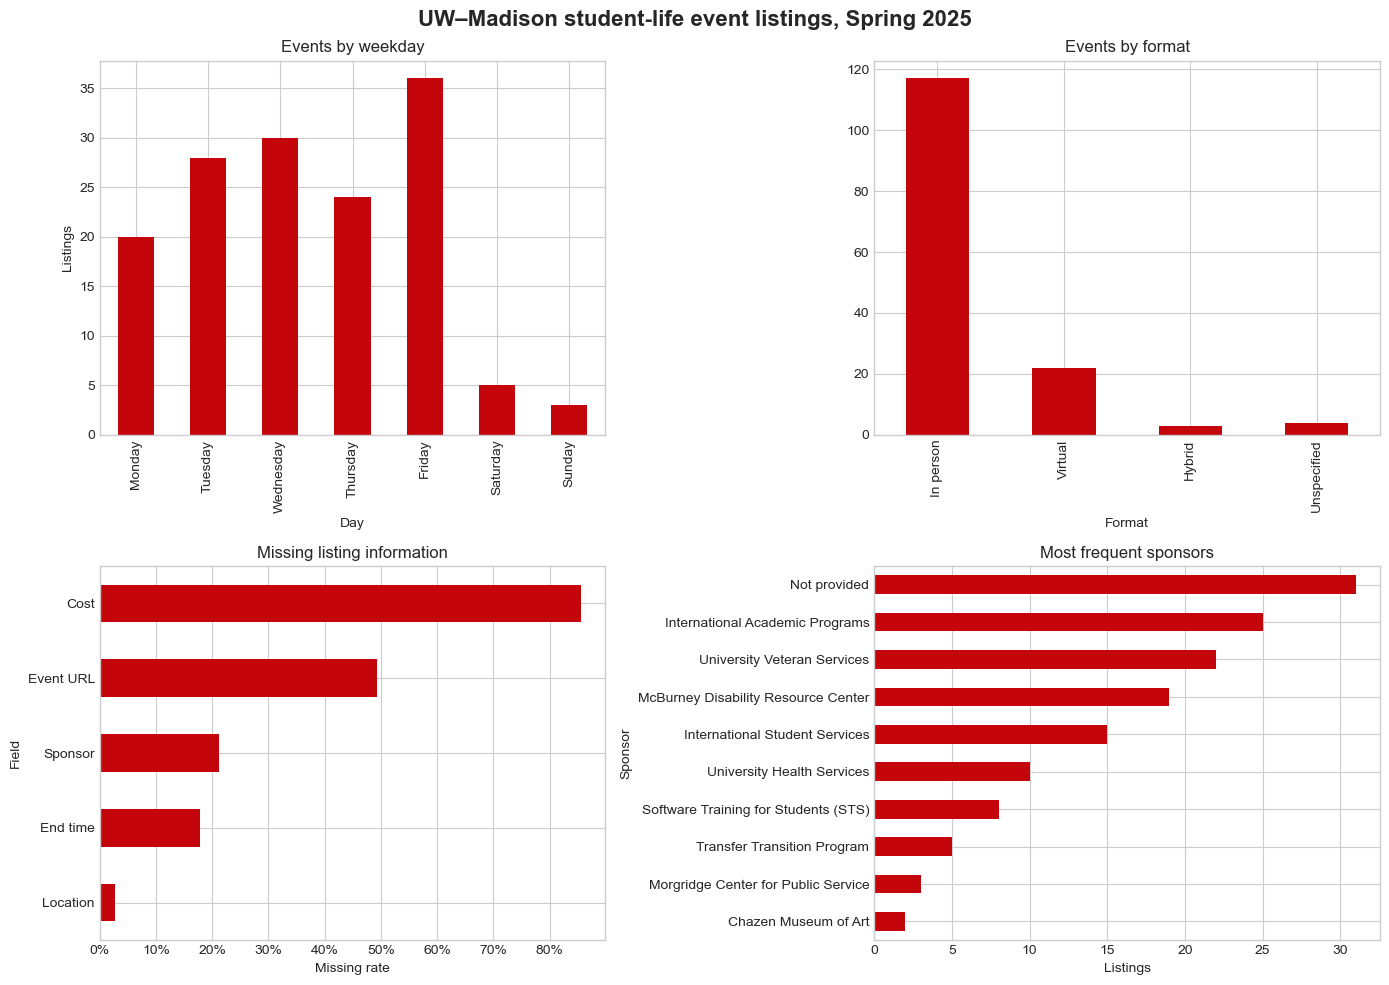

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
color = "#C5050C"

weekday_counts.plot.bar(x="Day", y="Events", ax=axes[0, 0], color=color, legend=False, title="Events by weekday")
format_counts.plot.bar(x="Format", y="Events", ax=axes[0, 1], color=color, legend=False, title="Events by format")
missing_counts.sort_values("Missing rate").plot.barh(
    x="Field", y="Missing rate", ax=axes[1, 0], color=color, legend=False, title="Missing listing information"
)
sponsor_counts.sort_values("Events").plot.barh(
    x="Sponsor", y="Events", ax=axes[1, 1], color=color, legend=False, title="Most frequent sponsors"
)

axes[0, 0].set_ylabel("Listings")
axes[1, 0].set_xlabel("Missing rate")
axes[1, 0].xaxis.set_major_formatter(PercentFormatter(1))
axes[1, 1].set_xlabel("Listings")
fig.suptitle("UW–Madison student-life event listings, Spring 2025", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Findings and implications

- **Scheduling:** Friday had the most listings (36), while only eight of 146 events were listed on weekends.
- **Completeness:** Cost was blank for 125 listings, event URL for 72, sponsor for 31, end time for 26, and location for four.
- **Format:** 117 events were in person, 22 virtual, three hybrid, and four unspecified.
- **Representation:** Only 15 named sponsors appeared. Women in Business Technology and the Information Systems Society did not appear by name in this sample.

## 7. Proposed UW–Tether partnership

UW organizers currently enter events manually through `admin.today.wisc.edu`, select tags, and decide whether to share them campus-wide. Clubs may be missing from this sample because they use other promotion channels, assign no clear owner for calendar updates, choose different tags, use another sponsor name, or keep events private. These are hypotheses, not conclusions from the API data.

The public API is read-only. Tether could import UW listings, but direct submission would require an approved university partnership. A practical model would divide responsibilities as follows:

| Participant | Proposed role |
|---|---|
| Student organizations | Submit and maintain complete event details |
| Tether | Verify organization ownership, validate required fields, support discovery, and measure engagement |
| UW–Madison | Set governance rules, approve submissions or integrations, and maintain the official calendar |

```text
Verified organization -> Tether validation -> approved UW submission
UW calendar -> public API -> Tether discovery
Tether activity -> engagement reporting
```

Tether should require sponsor, category, time, format, location or link, cost, and registration details. Its reporting layer could then add views, saves, registrations, attendance, and organization participation.

### Benefits

- **UW–Madison:** broader event coverage, more consistent records, and better evidence for scheduling, outreach, funding, and engagement decisions.
- **Student organizations:** one structured submission process, wider discovery, and feedback on which listings generate interest.
- **Students:** a more complete and trustworthy discovery experience with relevant recommendations.

Before implementation, the partners would need to define submission approval, data ownership, privacy and retention, duplicate handling, synchronization timing, and whether engagement data may be shared in aggregate. This is a proposed operating model, not a current UW integration.

Sources: [UW submission guidance](https://kb.wisc.edu/communications/149248) and [UW Events API](https://today.wisc.edu/api-docs/).

## 8. Save the cleaned data

The processed CSV can be reused in SQL, Excel, Tableau, or Power BI.

In [7]:
events_df.to_csv("data/processed/uw_student_life_events_spring_2025.csv", index=False)

## Limitations

- The dataset covers approximately one semester and only listings tagged `student life`.
- Inclusion depends on manual submission and correct tagging.
- Organizations may appear under different sponsor names or promote events outside the calendar.
- Absence from the sample does not mean an organization was inactive.
- Historical edits and recurring listings may affect event counts.
- The API provides listing information rather than attendance or engagement data.
- The analysis cannot determine why an organization did not submit an event.
- Public contact emails and phone numbers were removed because they were not needed for this analysis.